<a href="https://colab.research.google.com/github/jeevanshrestha/GenAi/blob/main/Agentic_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Agentic RAG


### Initial Setup

#### Install Required Libraries


In [3]:
!pip install openai langchain langchain-community langchain_huggingface langchain-openai unstructured faiss-cpu grandalf langgraph   -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.4/152.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━

#### Mount Google Drive

In [4]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#set working directory
import os
os.chdir('/content/drive/MyDrive/GenAI/RAG/')

directory = os.getcwd()
file_path = os.path.join(directory, 'Agentic RAG')

#### OpenAI Key Setup

In [6]:
from google.colab import userdata
api_key = userdata.get('genai_course')

#### Import Libraries


In [7]:
#Import the libraries
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import UnstructuredExcelLoader
from langchain.vectorstores.faiss import FAISS
from langchain.prompts import ChatPromptTemplate
from langchain.schema.output_parser import  StrOutputParser
from langgraph.graph import StateGraph, END
from langchain.prompts.chat import SystemMessagePromptTemplate, HumanMessagePromptTemplate

from IPython.display import display, Markdown, Image
import json
import numpy as np
import pandas as pd
from typing import List
from typing_extensions import TypedDict


In [8]:
print(os.getcwd())

/content/drive/MyDrive/GenAI/RAG


In [9]:
file = os.path.join(file_path, "dim sum montijo.xlsx")
loader = UnstructuredExcelLoader(file, mode ="elements")

data = loader.load()

In [10]:
# Initialize the embeddings model with the OpenAI API key
embeddings = OpenAIEmbeddings(openai_api_key=api_key)

# Create a vector store (FAISS) from the documents using the embeddings
db = FAISS.from_documents(data, embeddings)

### Process

We define a custom TypedDict class to keep track of the agent's state and implement functions representing different steps in the agent's workflow.

AgentState stores all the necessary information about the current state of the conversation.

In [11]:
# Define a TypedDict to store the agent's state
class AgentState(TypedDict):
    start: bool             # Indicates if the conversation has started
    conversation: int       # Keeps track of conversation turns
    question: str           # Customer's question
    answer: str             # Agent's answer
    topic: bool             # Decision on whether the question is appropriate
    documents: list         # Relevant documents retrieved
    recursion_limit: int    # To avoid endless loops
    memory: list            # Conversation history

In [12]:
# Greet the customer
def greetings(state):
  print("Hello ! welcome to the restaurant. I will be your waiter. How can I help you?")
  user_input = input()
  # Update the state with the customer's question and initialize conversation variables
  state['question'] = user_input
  state['conversation'] = 1
  state['memory'] = [user_input]

  return state

We need to assess if the customer's question is appropriate for a waiter to answer

In [13]:
def check_question(state):
    # Get the customer's question from the state
    question = state['question']

    # Define the system prompt to evaluate the question's appropriateness
    system_prompt = """
    You are a grader evaluating the appropriateness of a customer's question to a waiter or waitress in a restaurant.
    Assess if the question is suitable to ask the restaurant staff and if the customer shows interest in continuing the conversation.
    Respond with "True" if the question is appropriate for the staff or indicates the customer is asking a question or giving you information.
    Otherwise respond with "False".
    Provide only "True" or "False" in your response.
    """

    # Create a prompt template for formatting
    TEMPLATE = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "User question: {question}"),
    ])


    # Format the prompt with the customer's question
    prompt = TEMPLATE.format(question=question)

    # Initialize the language model
    model = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

    # Invoke the model with the prompt
    response_text = model.invoke(prompt)

    # Update the state with the model's decision
    state['topic'] = response_text.content.strip()

    return state

In [14]:
# Function to check if the LLM model decides if the question is on topic on top
def topic_router(state):
  topic = state['topic']
  if topic == "True":
    return "on_topic"
  else:
    return "off_topic"


# Function for when the question is Not on Topic

def off_topic_response(state):
  if state['conversation']<=1:
    state['answer'] ="\nI apologize, I can't answer that question. I can only answer question about the menu"
  else:
    state['answer'] = "\n Happy to help"
  print(state['answer'])
  return state





In [24]:
## Retrieve relevant document based on the question
def retrieve_docs(state):
    # Combine the conversation history into a single string
    memory = " ".join(state['memory'])

    # Retrieve the top 5 relevant documents based on similarity to the conversation history
    docs_faiss = db.similarity_search(memory, k=5)

    # Store the retrieved documents' content in the state
    state['documents'] = [doc.page_content for doc in docs_faiss]

    return state


In [25]:
## Function to generate with LLM
# Build a function to generate the questions
def generate(state):
  # Initializing the model
  model = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

  # Extract the information
  question = state['question']
  documents = state['documents']
  memory = state['memory']

  # Define the system prompt for the model
  system_prompt = """
  You are a waiter at a restaurant tasked with answering the customer's question.
  Answer the question in the manner of a waiter, avoiding being too verbose.
  Do not include "waiter" or refer to yourself explicitly in your answer"""

  # Create a prompt template for formatting
  TEMPLATE = ChatPromptTemplate.from_messages([
      ("system", system_prompt),
      ("human", f"Context: {documents}\nConversation history so far: {memory}\nCustomer question: {question}")
  ])

  # Format the prompt
  prompt = TEMPLATE.format(documents = documents, memory = memory, question = question)

  # Invoke the model with the formatted prompt
  response_text = model.invoke(prompt)

  # Update the state with the model's response
  state['answer'] = response_text.content.strip()
  print(state['answer'])

  return state

In [31]:
def improve_answer(state):
    # Extract necessary information from the state
    question = state['question']
    answer = state['answer']
    memory = state['memory']

    # Define the system prompt for refining the answer
    system = """
    As a waiter, review and refine the response to a customer's question. Your task is to:

    1. Ensure the answer is appropriate, friendly, and informative.
    2. Edit or remove parts of the answer as needed, without adding new information.
    3. Maintain a polite, professional, and attentive tone.
    4. Provide only the improved answer, without any introductory phrases or commentary.
    5. Conclude the response with an open-ended question to invite further inquiries or address additional needs.
    6. Consider the conversation history to be more informative and useful.
    7. Include line breaks (`\n`) at the end of each sentence or logical break.

    Deliver a refined response that enhances the customer's experience and reflects the restaurant's commitment to customer service.
    """

    # Create a prompt template for formatting
    TEMPLATE = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", "Customer question: {question}\nConversation history: {memory}\nWaiter's initial answer: {answer}"),
    ])

    # Initialize the language model
    model = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

    # Format the prompt with the necessary information
    prompt = TEMPLATE.format(question=question, memory=memory, answer=answer)

    # Invoke the model to improve the answer
    response_text = model.invoke(prompt)

    # Update the state with the improved answer
    state['answer'] = response_text.content.strip()

    # Display the improved answer
    print('\n')
    print(state['answer'])

    # Append the improved answer to the conversation history
    state['memory'].append(state['answer'])

    return state

In [32]:
def further_question(state):
    # Prompt the customer for further input
    print('\n')
    user_input = input()

    # Update the state with the new question and increment the conversation turn
    state['question'] = user_input
    state['conversation'] += 1
    state['memory'].append(user_input)

    return state


## Workflow

In [35]:
# Initializaing a StateGraph
workflow = StateGraph(AgentState)

# Defining the nodes
workflow.add_node("greetings", greetings)

workflow.add_node("check_question", check_question)

workflow.add_node("retrieve_docs", retrieve_docs)

workflow.add_node("generate", generate)

workflow.add_node("improve_answer", improve_answer)

workflow.add_node("further_question", further_question)

workflow.add_node("off_topic_response", off_topic_response)

# Set the entry point to the workflow
workflow.set_entry_point("greetings")


# Add the conditional
# Add conditional edges based on the topic_router function's output
workflow.add_conditional_edges(
    "check_question",
    topic_router,
    {
        "on_topic": "retrieve_docs",
        "off_topic": "off_topic_response"
    }
)


# Add sequential edges
workflow.add_edge("greetings", "check_question")

workflow.add_edge("off_topic_response", END)

# Add sequential edges
workflow.add_edge("retrieve_docs", "generate")

workflow.add_edge("generate", "improve_answer")

workflow.add_edge("improve_answer", "further_question")

workflow.add_edge("further_question", "check_question")

# Compile the workflow into an application
app = workflow.compile()

In [37]:
# Test the app
result = app.invoke({"start":True, "recursion_limit":50})

Hello ! welcome to the restaurant. I will be your waiter. How can I help you?
what is the best soup?
The Won Ton Soup is a popular choice, featuring rich flavors with pork and shrimp. If you prefer something lighter, the Vegetarian Soup with bamboo, mushrooms, and vegetables is also highly recommended. Would you like to try one?


The Won Ton Soup is a popular choice, showcasing rich flavors with pork and shrimp.  

If you prefer something lighter, the Vegetarian Soup, made with bamboo, mushrooms, and fresh vegetables, is also highly recommended.  

Would you like to try one of these soups, or do you have any other questions?


any pork soup available?
Yes, we have the Won Ton Soup, which features pork along with shrimp. It's a delicious option if you're looking for a pork-based soup. Would you like to order it?


Yes, we have the Won Ton Soup, which features pork along with shrimp.  

It's a delicious option if you're looking for a pork-based soup.  

Would you like to hear more about

### Preview the workflow

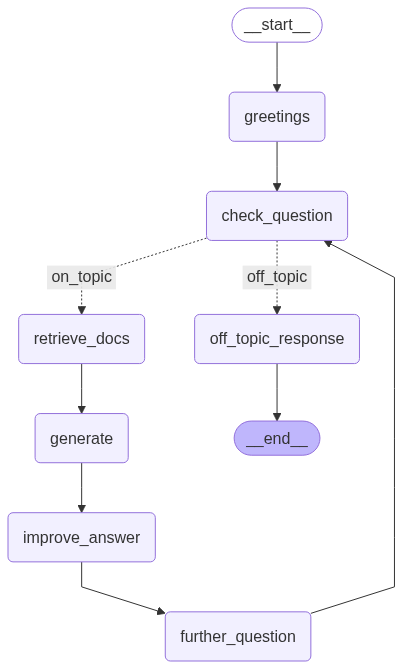

In [36]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))